# MLB Expected Whiff Model

## Project Overview

This project builds a machine learning model to estimate the probability that an MLB pitch results in a swing and miss. Using Statcast pitch-level data from the 2025 MLB season, the model evaluates pitch characteristics and game context to calculate an expected whiff probability, or xWhiff, for each pitch.

The goal is not only to predict whiffs, but also to compare expected and actual results to identify pitch types and individual pitcher-pitch combinations that generated more whiffs than the model expected.

### Research Question

Given the characteristics and context of an MLB pitch, how likely is it to generate a swing and miss, and which pitches outperform that expectation?

## 1. Data Loading and Preparation

The dataset contains MLB Statcast pitch-level data from the 2025 season. Each row represents an individual pitch and includes information about the pitcher, pitch type, velocity, movement, spin, location, count, and pitch outcome.

The data is loaded and sorted chronologically so that later observations can be reserved for out-of-sample model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

data = pd.read_csv(
    "../data/statcast_2025_full.csv",
    low_memory=False
)

data["game_date"] = pd.to_datetime(data["game_date"])

print(f"Total pitches: {len(data):,}")
print(f"Total whiffs: {data['whiff'].sum():,}")
print(f"Overall whiff rate: {data['whiff'].mean():.2%}")

print(
    f"Date range: "
    f"{data['game_date'].min().date()} to "
    f"{data['game_date'].max().date()}"
)

Total pitches: 711,897
Total whiffs: 78,023
Overall whiff rate: 10.96%
Date range: 2025-03-27 to 2025-09-28


In [2]:
# Handedness matchup
data["same_side"] = (
    data["p_throws"] == data["stand"]
).astype(int)

# Count state
data["two_strikes"] = (
    data["strikes"] == 2
).astype(int)

data["three_balls"] = (
    data["balls"] == 3
).astype(int)

# Normalize vertical location using each hitter's strike zone
zone_height = data["sz_top"] - data["sz_bot"]

data["plate_z_norm"] = (
    (data["plate_z"] - data["sz_bot"]) /
    zone_height
)

# Distance from approximate horizontal center
data["abs_plate_x"] = data["plate_x"].abs()

/var/folders/7q/przjg2zj30703yqz3jgm4y7c0000gn/T/ipykernel_70943/903437271.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["same_side"] = (
/var/folders/7q/przjg2zj30703yqz3jgm4y7c0000gn/T/ipykernel_70943/903437271.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["two_strikes"] = (
/var/folders/7q/przjg2zj30703yqz3jgm4y7c0000gn/T/ipykernel_70943/903437271.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consi

## 2. Target Definition and Feature Selection

The target variable for the model is `whiff`, which indicates whether an individual pitch resulted in a swing and miss.

The model uses information available at or immediately after pitch release, including pitch velocity, spin rate, movement, release extension, pitch location, pitch type, count, pitcher handedness, and batter handedness.

These features allow the model to estimate the expected probability of a whiff based on the characteristics and context of each pitch.

In [3]:
numeric_features = [
    "release_speed",
    "release_spin_rate",
    "pfx_x",
    "pfx_z",
    "plate_x",
    "plate_z_norm",
    "abs_plate_x",
    "release_extension",
    "balls",
    "strikes",
    "same_side",
    "two_strikes",
    "three_balls"
]

categorical_features = [
    "pitch_type",
    "p_throws",
    "stand"
]

target = "whiff"

model_columns = (
    numeric_features +
    categorical_features +
    [target, "game_date"]
)

model_data = data[model_columns].copy()

print(f"Modeling observations: {len(model_data):,}")

model_data.head()

Modeling observations: 711,897


,release_speed,release_spin_rate,pfx_x,pfx_z,plate_x,plate_z_norm,abs_plate_x,release_extension,balls,strikes,same_side,two_strikes,three_balls,pitch_type,p_throws,stand,whiff,game_date
0,96.3,2197.0,-1.33,0.52,0.064893,0.771337,0.064893,6.6,2,1,1,0,0,SI,R,R,0,2025-04-30
1,86.8,2346.0,0.73,0.22,0.873167,0.251637,0.873167,6.4,1,1,1,0,0,ST,R,R,0,2025-04-30
2,96.2,2232.0,-1.33,0.58,0.317688,0.812060,0.317688,6.6,1,0,1,0,0,SI,R,R,0,2025-04-30
3,90.5,2306.0,0.15,0.58,-0.454558,1.960073,0.454558,6.4,0,0,1,0,0,FC,R,R,0,2025-04-30
4,97.2,2251.0,-1.35,0.72,0.548554,0.272673,0.548554,6.6,1,2,1,1,0,SI,R,R,0,2025-04-30


## 3. Chronological Train-Test Split

To evaluate the model on pitches it has not previously seen, the data is divided chronologically rather than using a random train-test split.

Pitches from March through August 2025 are used for model training, while September 2025 is reserved as the test set. This better represents how the model would perform in practice by training on past data and predicting future pitches.

The September data is not used during model training.

In [4]:
train = model_data[
    model_data["game_date"] < "2025-09-01"
].copy()

test = model_data[
    model_data["game_date"] >= "2025-09-01"
].copy()

X_train = train[
    numeric_features + categorical_features
]

y_train = train[target]

X_test = test[
    numeric_features + categorical_features
]

y_test = test[target]

print("TRAINING DATA")
print(f"Pitches: {len(train):,}")
print(
    f"Dates: {train['game_date'].min().date()} "
    f"to {train['game_date'].max().date()}"
)
print(f"Whiff rate: {y_train.mean():.2%}")

print()

print("TEST DATA")
print(f"Pitches: {len(test):,}")
print(
    f"Dates: {test['game_date'].min().date()} "
    f"to {test['game_date'].max().date()}"
)
print(f"Whiff rate: {y_test.mean():.2%}")

TRAINING DATA
Pitches: 601,559
Dates: 2025-03-27 to 2025-08-31
Whiff rate: 10.85%

TEST DATA
Pitches: 110,338
Dates: 2025-09-01 to 2025-09-28
Whiff rate: 11.56%


## 4. Data Preprocessing

Before model training, numeric and categorical features are processed separately using a Scikit-learn preprocessing pipeline.

Missing numeric values are replaced using the median of the training data and numeric features are standardized. Missing categorical values are also handled before categorical variables are converted into numeric representations using one-hot encoding.

Using a preprocessing pipeline ensures that the same transformations learned from the training data are consistently applied to the September test set.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessor ready.")

Preprocessor ready.


## 5. Logistic Regression Baseline

A logistic regression model is used as the first predictive model. Logistic regression provides a relatively simple and interpretable baseline for determining how well pitch characteristics can distinguish between whiffs and non-whiffs.

The model outputs a probability of a whiff for each pitch in the September test set. Performance is evaluated using ROC-AUC and Log Loss.

ROC-AUC measures the model's ability to rank pitches by their likelihood of producing a whiff, while Log Loss evaluates the quality of the predicted probabilities. Higher ROC-AUC and lower Log Loss indicate better model performance.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_probability = (
    logistic_model.predict_proba(X_test)[:, 1]
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probability
)

logistic_loss = log_loss(
    y_test,
    logistic_probability
)

print("LOGISTIC REGRESSION")
print("-------------------")
print(f"ROC-AUC:  {logistic_auc:.3f}")
print(f"Log Loss: {logistic_loss:.3f}")

LOGISTIC REGRESSION
-------------------
ROC-AUC:  0.648
Log Loss: 0.345


## 6. Gradient Boosting Model

A gradient boosting model is used to capture more complex relationships between pitch characteristics and whiff probability. Unlike logistic regression, gradient boosting can model nonlinear relationships and interactions between variables such as pitch location, velocity, movement, count, and pitch type.

The model uses the same training and test data as the logistic regression model, allowing the two approaches to be compared directly. Performance is again evaluated using ROC-AUC and Log Loss.

The gradient boosting model is expected to improve upon the logistic regression baseline by capturing patterns that a linear model may not identify.

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier

gradient_boosting_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            HistGradientBoostingClassifier(
                learning_rate=0.08,
                max_iter=200,
                max_leaf_nodes=31,
                min_samples_leaf=30,
                l2_regularization=1.0,
                random_state=42
            )
        )
    ]
)

gradient_boosting_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting training complete.")

Gradient Boosting training complete.


## 7. Model Performance Comparison

The two models are evaluated on the September test data using ROC-AUC and Log Loss.

ROC-AUC measures how well the model distinguishes between pitches that result in whiffs and pitches that do not. A higher ROC-AUC indicates better discrimination.

Log Loss evaluates the quality of the predicted probabilities and penalizes predictions that are confidently incorrect. A lower Log Loss indicates better probability estimates.

Comparing these metrics allows us to determine whether the more flexible gradient boosting model provides a meaningful improvement over the logistic regression baseline.

In [8]:
gb_probability = (
    gradient_boosting_model
    .predict_proba(X_test)[:, 1]
)

gb_auc = roc_auc_score(
    y_test,
    gb_probability
)

gb_loss = log_loss(
    y_test,
    gb_probability
)

print("MODEL COMPARISON")
print("----------------")

print(
    f"Logistic Regression | "
    f"AUC: {logistic_auc:.3f} | "
    f"Log Loss: {logistic_loss:.3f}"
)

print(
    f"Gradient Boosting    | "
    f"AUC: {gb_auc:.3f} | "
    f"Log Loss: {gb_loss:.3f}"
)

MODEL COMPARISON
----------------
Logistic Regression | AUC: 0.648 | Log Loss: 0.345
Gradient Boosting    | AUC: 0.751 | Log Loss: 0.316


## 8. Comparison to a Constant Baseline

To provide additional context for model performance, a constant baseline model is included. The baseline assigns every pitch the same predicted whiff probability, equal to the average whiff rate in the training data.

This represents a model with no ability to distinguish between individual pitches. Comparing the logistic regression and gradient boosting models against this baseline helps demonstrate how much predictive information is gained from the pitch characteristics included in the model.

In [9]:
baseline_probability = np.full(
    len(y_test),
    y_train.mean()
)

baseline_auc = roc_auc_score(
    y_test,
    baseline_probability
)

baseline_loss = log_loss(
    y_test,
    baseline_probability
)

comparison = pd.DataFrame({
    "Model": [
        "Constant Baseline",
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "ROC-AUC": [
        baseline_auc,
        logistic_auc,
        gb_auc
    ],
    "Log Loss": [
        baseline_loss,
        logistic_loss,
        gb_loss
    ]
})

comparison

,Model,ROC-AUC,Log Loss
0,Constant Baseline,0.500000,0.358263
1,Logistic Regression,0.648383,0.344612
2,Gradient Boosting,0.750613,0.315933


## 9. ROC Curve Analysis

The ROC curve provides a visual comparison of how well each model distinguishes between pitches that result in a whiff and pitches that do not.

A model with no predictive ability would follow the diagonal line and have a ROC-AUC of 0.500. Curves farther toward the upper-left corner indicate stronger predictive performance.

The gradient boosting model achieves a ROC-AUC of 0.751 compared with 0.648 for logistic regression, showing that the gradient boosting model is substantially better at separating higher-probability whiff pitches from lower-probability pitches.

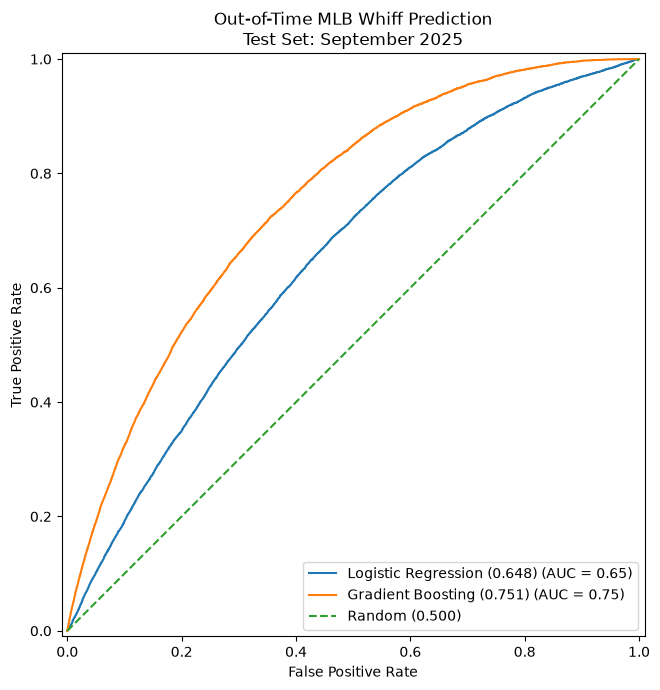

In [10]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(9, 7))

RocCurveDisplay.from_predictions(
    y_test,
    logistic_probability,
    name=f"Logistic Regression ({logistic_auc:.3f})",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    gb_probability,
    name=f"Gradient Boosting ({gb_auc:.3f})",
    ax=ax
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random (0.500)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Out-of-Time MLB Whiff Prediction\n"
    "Test Set: September 2025"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/final_model_roc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Expected Whiff Analysis

After evaluating the model, the gradient boosting predictions are applied to each pitch in the September test set. The predicted probability of a whiff is referred to as expected whiff probability, or xWhiff.

These predictions can be aggregated by pitch type and by individual pitcher-pitch combinations. Comparing expected whiff rate with actual whiff rate allows us to identify pitches that generated more or fewer whiffs than the model expected based on their characteristics and context.

This provides a way to move beyond overall model performance and use the model to evaluate individual pitches and pitcher arsenals.

In [11]:
# Create results dataframe from the original September data
test_results = data.loc[test.index].copy()

# Add model predictions
test_results["xWhiff"] = gb_probability
test_results["Whiff"] = y_test.values

print(f"September pitches: {len(test_results):,}")

# Check available information
test_results[
    [
        "pitcher",
        "player_name",
        "pitch_type",
        "release_speed",
        "release_spin_rate",
        "plate_x",
        "plate_z",
        "xWhiff",
        "Whiff"
    ]
].head(10)

September pitches: 110,338


,pitcher,player_name,pitch_type,release_speed,release_spin_rate,plate_x,plate_z,xWhiff,Whiff
601559,669711,"Weissert, Greg",FF,95.7,2370.0,-0.395886,3.083176,0.120790,0
601560,669711,"Weissert, Greg",FF,95.1,2309.0,0.567564,2.593190,0.096243,0
601561,669711,"Weissert, Greg",FF,95.4,2314.0,0.055280,3.301461,0.209508,0
601562,669711,"Weissert, Greg",SL,84.8,2528.0,0.142130,2.594828,0.110141,1
601563,669711,"Weissert, Greg",SL,85.3,2548.0,0.934337,2.571056,0.105529,0
601564,669711,"Weissert, Greg",SI,95.2,2148.0,0.736511,1.984434,0.030439,0
601565,669711,"Weissert, Greg",FF,95.3,2435.0,1.050086,2.502560,0.083678,0
601566,669711,"Weissert, Greg",SI,95.0,2175.0,0.252684,1.897654,0.042767,0
601567,669711,"Weissert, Greg",FF,95.5,2338.0,0.578097,3.022850,0.186050,0
601568,669711,"Weissert, Greg",FF,94.9,2413.0,1.194208,2.929027,0.049091,0


## 11. Expected Whiff Rate by Pitch Type

The model predictions are first aggregated by pitch type to compare the expected and actual whiff rates of different pitch classifications.

For each pitch type, xWhiff represents the average whiff probability predicted by the gradient boosting model, while Actual Whiff represents the observed percentage of pitches that resulted in a swing and miss.

Only pitch types with at least 100 pitches in the September test set are included. This helps reduce the influence of very small samples and provides a more meaningful comparison across pitch types.

In [12]:
pitch_type_xwhiff = (
    test_results
    .groupby("pitch_type")
    .agg(
        Pitches=("pitch_type", "size"),
        xWhiff=("xWhiff", "mean"),
        Actual_Whiff=("Whiff", "mean")
    )
    .query("Pitches >= 100")
    .sort_values("xWhiff", ascending=False)
)

pitch_type_xwhiff["xWhiff"] *= 100
pitch_type_xwhiff["Actual_Whiff"] *= 100

pitch_type_xwhiff.round(2)

,Pitches,xWhiff,Actual_Whiff
pitch_type,,,
FS,3471,16.35,18.50
SL,15623,15.09,15.80
KC,1952,15.03,14.75
CH,12147,14.45,15.23
ST,8307,13.15,15.23
SV,431,13.11,14.62
CU,7840,12.46,12.58
FC,7245,10.22,11.03
FF,36263,9.17,9.49


## 12. Pitcher and Pitch Type Expected Whiff Analysis

To evaluate individual pitches at the pitcher level, the September test data is grouped by pitcher and pitch type.

For each pitcher and pitch-type combination, the analysis calculates the number of pitches thrown, average expected whiff probability, actual whiff rate, average velocity, and average spin rate.

This allows the model to identify specific pitches that are expected to generate high whiff rates and provides additional context about the characteristics of those pitches.

In [13]:
pitcher_pitch_xwhiff = (
    test_results
    .groupby(
        [
            "pitcher",
            "player_name",
            "pitch_type"
        ]
    )
    .agg(
        Pitches=("pitch_type", "size"),
        xWhiff=("xWhiff", "mean"),
        Actual_Whiff=("Whiff", "mean"),
        Avg_Velocity=("release_speed", "mean"),
        Avg_Spin=("release_spin_rate", "mean")
    )
    .query("Pitches >= 100")
    .reset_index()
)

pitcher_pitch_xwhiff["xWhiff"] *= 100
pitcher_pitch_xwhiff["Actual_Whiff"] *= 100

pitcher_pitch_xwhiff = (
    pitcher_pitch_xwhiff
    .sort_values("xWhiff", ascending=False)
)

pitcher_pitch_xwhiff.head(20).round(2)

,pitcher,player_name,pitch_type,Pitches,xWhiff,Actual_Whiff,Avg_Velocity,Avg_Spin
7,518585,"Cruz, Fernando",FS,128,21.73,22.66,81.02,882.90
72,642207,"Williams, Devin",CH,101,19.92,18.81,84.41,2716.46
124,666214,"Wentz, Joey",SL,127,19.69,16.54,84.09,2503.85
89,656945,"Scott, Tanner",SL,112,19.24,25.89,90.59,2652.29
126,668678,"Gallen, Zac",CH,121,18.84,17.36,85.48,1528.00
32,594798,"deGrom, Jacob",SL,121,18.40,23.14,91.65,2704.83
78,650911,"Sánchez, Cristopher",CH,139,18.29,27.34,87.02,2047.71
18,571578,"Corbin, Patrick",SL,120,18.17,18.33,81.68,2256.82
175,676282,"Cantillo, Joey",CH,117,18.15,24.79,79.58,1516.37
24,592332,"Gausman, Kevin",FS,185,18.02,22.16,84.45,1528.58


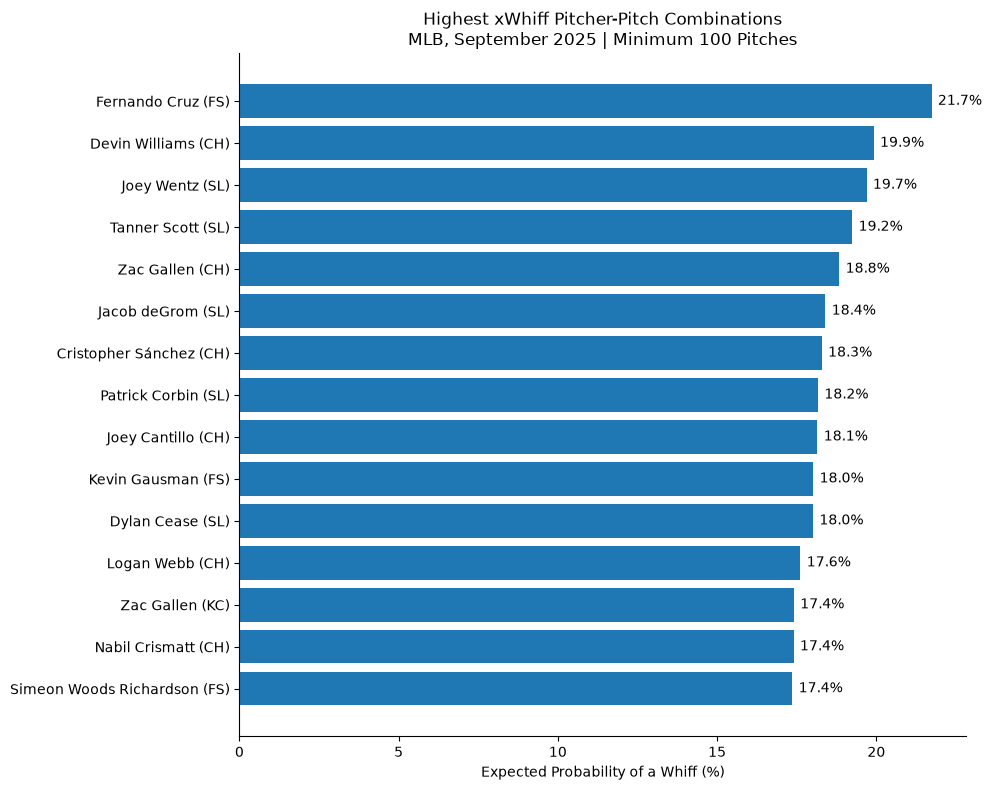

In [14]:
# Clean pitcher names for display
leaderboard = pitcher_pitch_xwhiff.head(15).copy()

leaderboard["Pitcher"] = (
    leaderboard["player_name"]
    .str.split(", ")
    .str[::-1]
    .str.join(" ")
)

# Add pitch type to label
leaderboard["Label"] = (
    leaderboard["Pitcher"]
    + " ("
    + leaderboard["pitch_type"]
    + ")"
)

# Sort for horizontal chart
leaderboard = leaderboard.sort_values(
    "xWhiff",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    leaderboard["Label"],
    leaderboard["xWhiff"]
)

# Add probability labels
for bar, value in zip(bars, leaderboard["xWhiff"]):
    ax.text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

ax.set_xlabel("Expected Probability of a Whiff (%)")
ax.set_ylabel("")

ax.set_title(
    "Highest xWhiff Pitcher-Pitch Combinations\n"
    "MLB, September 2025 | Minimum 100 Pitches"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../figures/xwhiff_leaderboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13. Whiff Above Expected

Expected whiff probability provides a baseline for how often a pitch should generate a swing and miss based on its characteristics and game context.

To identify pitches that performed better than expected, Whiff Above Expected is calculated as the difference between the actual whiff rate and the model's expected whiff rate.

A positive value indicates that a pitch generated more whiffs than expected, while a negative value indicates that it generated fewer whiffs than expected. Only pitcher and pitch-type combinations with at least 50 pitches in the September test set are included.

In [15]:
overperformance = pitcher_pitch_xwhiff.copy()

overperformance["Whiff_Above_Expected"] = (
    overperformance["Actual_Whiff"]
    - overperformance["xWhiff"]
)

overperformance = (
    overperformance
    .sort_values(
        "Whiff_Above_Expected",
        ascending=False
    )
)

overperformance[
    [
        "player_name",
        "pitch_type",
        "Pitches",
        "xWhiff",
        "Actual_Whiff",
        "Whiff_Above_Expected"
    ]
].head(15).round(2)

,player_name,pitch_type,Pitches,xWhiff,Actual_Whiff,Whiff_Above_Expected
226,"Beeter, Clayton",SL,105,14.67,27.62,12.95
213,"Sheehan, Emmet",SL,135,13.85,25.19,11.33
118,"Ragans, Cole",FF,110,12.58,23.64,11.06
119,"Lodolo, Nick",CU,105,14.74,25.71,10.97
104,"Mize, Casey",FS,109,16.90,26.61,9.70
147,"Alexander, Jason",CH,117,13.15,22.22,9.07
78,"Sánchez, Cristopher",CH,139,18.29,27.34,9.05
56,"Díaz, Edwin",FF,103,10.64,19.42,8.77
55,"Enns, Dietrich",FF,124,11.27,19.35,8.08
235,"Elder, Bryce",SL,153,17.10,24.84,7.74


## 14. Actual vs Expected Whiff Rate

The following plot compares the model's expected whiff rate with the actual whiff rate for each qualifying pitcher and pitch-type combination.

Points above the diagonal line generated more whiffs than expected, while points below the line generated fewer whiffs than expected.

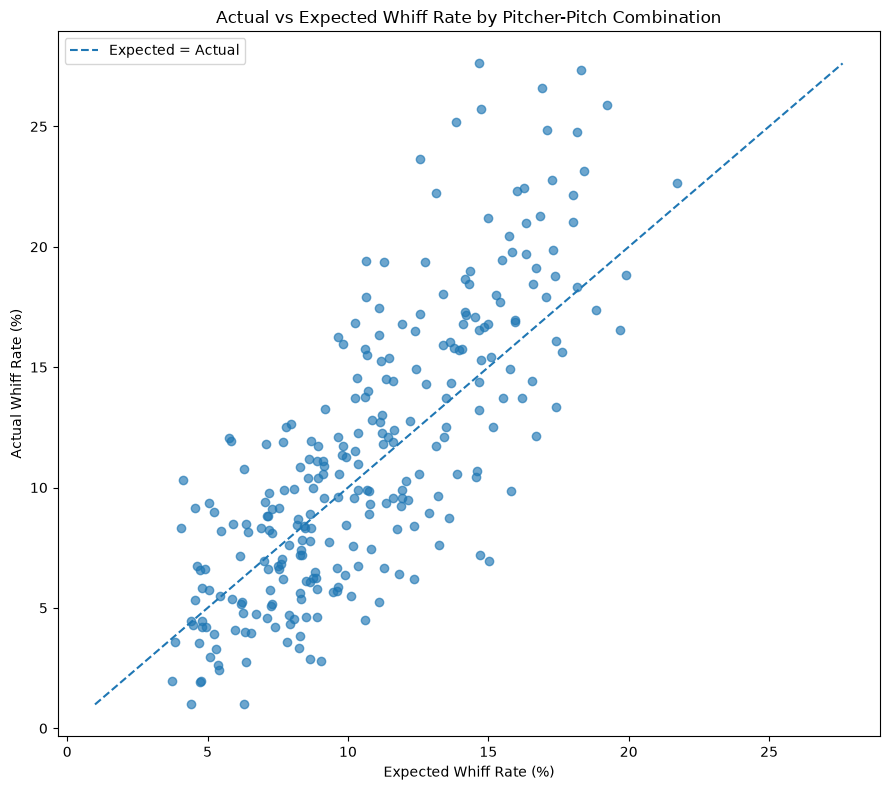

In [16]:
plt.figure(figsize=(9, 8))

plt.scatter(
    pitcher_pitch_xwhiff["xWhiff"],
    pitcher_pitch_xwhiff["Actual_Whiff"],
    alpha=0.65
)

# Perfect expectation line
min_val = min(
    pitcher_pitch_xwhiff["xWhiff"].min(),
    pitcher_pitch_xwhiff["Actual_Whiff"].min()
)

max_val = max(
    pitcher_pitch_xwhiff["xWhiff"].max(),
    pitcher_pitch_xwhiff["Actual_Whiff"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Expected = Actual"
)

plt.xlabel("Expected Whiff Rate (%)")
plt.ylabel("Actual Whiff Rate (%)")
plt.title("Actual vs Expected Whiff Rate by Pitcher-Pitch Combination")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../figures/ScatterPlot",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 15. Whiff Above Expected Leaderboard

The following visualization highlights the pitcher and pitch-type combinations that generated the largest positive difference between actual and expected whiff rate during the test period.

Only pitcher-pitch combinations meeting the minimum pitch threshold are considered.

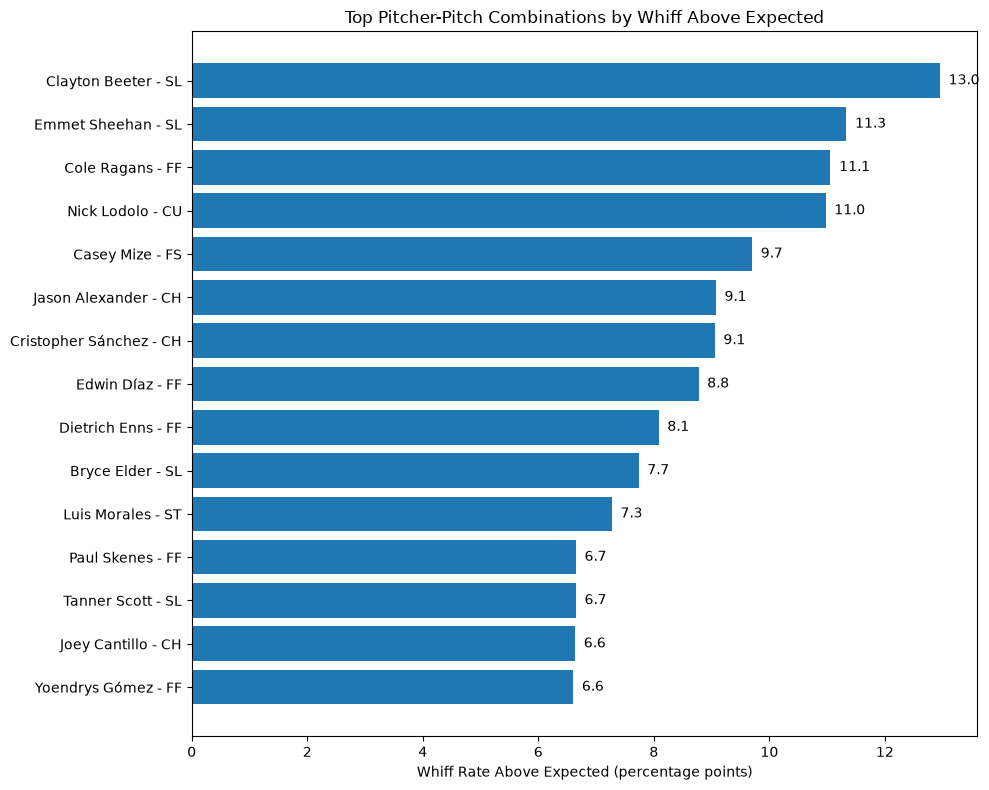

In [17]:
leaderboard = overperformance.head(15).copy()

leaderboard["Pitcher"] = (
    leaderboard["player_name"]
    .str.split(", ")
    .str[::-1]
    .str.join(" ")
)

leaderboard["Label"] = (
    leaderboard["Pitcher"]
    + " - "
    + leaderboard["pitch_type"]
)

leaderboard = leaderboard.sort_values(
    "Whiff_Above_Expected",
    ascending=True
)

plt.figure(figsize=(10, 8))

bars = plt.barh(
    leaderboard["Label"],
    leaderboard["Whiff_Above_Expected"]
)

plt.xlabel("Whiff Rate Above Expected (percentage points)")
plt.ylabel("")
plt.title("Top Pitcher-Pitch Combinations by Whiff Above Expected")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "../figures/TopCombo",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 16. Feature Importance

Permutation importance is used to estimate how strongly each input feature contributes to the Gradient Boosting model's predictive performance.

A feature is considered more important when randomly shuffling its values causes a larger decrease in model performance.

In [18]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    gradient_boosting_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

importance = (
    importance
    .sort_values("Importance", ascending=False)
    .head(15)
)

importance

,Feature,Importance
5,plate_z_norm,0.138502
13,pitch_type,0.071419
3,pfx_z,0.039012
6,abs_plate_x,0.038979
4,plate_x,0.029683
2,pfx_x,0.020902
9,strikes,0.015841
0,release_speed,0.009371
8,balls,0.005670
14,p_throws,0.004305


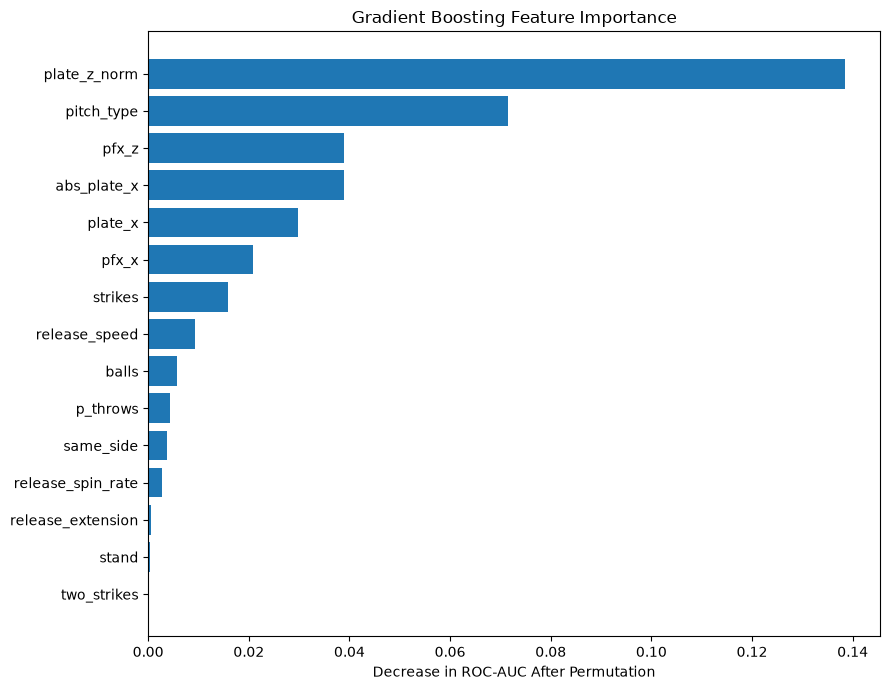

In [19]:
plot_importance = importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    plot_importance["Feature"],
    plot_importance["Importance"]
)

plt.xlabel("Decrease in ROC-AUC After Permutation")
plt.ylabel("")
plt.title("Gradient Boosting Feature Importance")

plt.tight_layout()

plt.savefig(
    "../figures/GradientImportantace",
    dpi=300,
    bbox_inches="tight"
)
plt.show()